In [1]:
# set up the python
from dask.distributed import Client
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import numpy as np
import xarray as xr
import cmocean as cm
import cartopy.crs as ccrs
import cmocean as cm
import cartopy.feature as cft
import cftime
import IPython.display
import sys, os, warnings
import matplotlib.animation as animation
from cartopy.mpl.geoaxes import GeoAxes  # Import GeoAxes for Cartopy plotting
from mpl_toolkits.axes_grid1 import AxesGrid
import gsw
from xhistogram.xarray import histogram as xhistogram
from xgcm import Grid
import intake

In [2]:

catalog = intake.cat.access_nri
client = Client(n_workers=28)

session = cc.database.create_session()
db = '/g/data/x77/hm1221/CDW_changes/Jupyter_notebooks/RYF_perturbation.db'
session1 = cc.database.create_session(db)

In [3]:
# time period 
start_time='2152-01-01'
end_time='2154-12-31'

In [4]:
tendency_th = xr.open_dataset('/scratch/x77/hm1221/nc_files/temp_tendency_terms/tendency_th_mean_3yrs.nc')
temp_tendency_th = tendency_th.temp_tendency_th
temp_advection_th= tendency_th.temp_advection_th
temp_vdiffuse_diff_cbt_th = tendency_th.temp_vdiffuse_diff_cbt_th
temp_nonlocal_KPP_th = tendency_th.temp_nonlocal_KPP_th
temp_submeso_th = tendency_th.temp_submeso_th
temp_rivermix_th = tendency_th.temp_rivermix_th
sw_heat_th = tendency_th.sw_heat_th

In [5]:
temp_tendency_th

<xarray.DataArray 'temp_tendency_th' (st_ocean: 75, yt_ocean_sub01: 741,
                                      xt_ocean_sub01: 3600)> Size: 800MB
[200070000 values with dtype=float32]
Coordinates:
  * st_ocean        (st_ocean) float64 600B 0.5413 1.681 ... 5.511e+03 5.709e+03
  * yt_ocean_sub01  (yt_ocean_sub01) float64 6kB -81.11 -81.07 ... -45.04 -44.97
  * xt_ocean_sub01  (xt_ocean_sub01) float64 29kB -279.9 -279.8 ... 79.85 79.95

In [6]:
tendency_th = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/tendency_th_mean_2yrs.nc')
pot_rho_1_th = tendency_th.pot_rho_1_th

In [7]:
bound_up_mean = xr.open_dataarray('/scratch/x77/hm1221/nc_files/bound_up_mean.nc')
bound_low_mean= xr.open_dataarray("/scratch/x77/hm1221/nc_files/bound_low_mean.nc")

In [8]:
# time period 
start_time1='2150-01-01'
end_time1='2150-12-31'

In [9]:
tendency_ctrl = xr.open_dataset('/scratch/x77/hm1221/nc_files/temp_tendency_terms/tendency_ctrl_mean_annual.nc')

temp_tendency_ctrl = tendency_ctrl.temp_tendency_ctrl
temp_advection_ctrl= tendency_ctrl.temp_advection_ctrl
temp_vdiffuse_diff_cbt_ctrl = tendency_ctrl.temp_vdiffuse_diff_cbt_ctrl
temp_nonlocal_KPP_ctrl = tendency_ctrl.temp_nonlocal_KPP_ctrl
temp_submeso_ctrl = tendency_ctrl.temp_submeso_ctrl
temp_rivermix_ctrl = tendency_ctrl.temp_rivermix_ctrl
sw_heat_ctrl = tendency_ctrl.sw_heat_ctrl

In [10]:
tendency_ctrl = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/tendency_ctrl_mean_annual.nc')
pot_rho_1_ctrl = tendency_ctrl.pot_rho_1_ctrl

In [11]:
# area of cells
area = catalog['01deg_jra55v13_ryf9091'].search(variable="area_t").to_dask()

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/source.py:306: ConcatenationWarning: Attempting to concatenate datasets without valid dimension coordinates: retaining only first dataset. Request valid dimension coordinate to silence this warning.
  warnings.warn(


In [12]:
area = area.area_t

In [13]:
st_ocean = xr.open_dataarray('/scratch/x77/hm1221/nc_files/st_ocean.nc')
shelf_mask = xr.open_dataarray('/scratch/x77/hm1221/nc_files/shelf_mask.nc')
## Get shelf mask
x_shelf = np.loadtxt('/scratch/x77/hm1221/nc_files/x_shelf.txt')
y_shelf = np.loadtxt('/scratch/x77/hm1221/nc_files/y_shelf.txt')

new_coord = xr.open_dataarray('/scratch/x77/hm1221/nc_files/lat_to_shelf_bin.nc')

In [14]:
new_coord_3d = new_coord.sel(yt_ocean = slice(-90,-44.96)).rename({'xt_ocean': 'xt_ocean_sub01', 'yt_ocean': 'yt_ocean_sub01'})
new_coord_2d = new_coord[0,:,:].sel(yt_ocean = slice(-90,-44.96))

In [15]:
def var_2d_time_mean(var):
    var_mean = var.mean('time').load()
    return var_mean

In [16]:
temp_tendency_ctrl = var_2d_time_mean(temp_tendency_ctrl)
temp_advection_ctrl= var_2d_time_mean(temp_advection_ctrl)
temp_vdiffuse_diff_cbt_ctrl = var_2d_time_mean(temp_vdiffuse_diff_cbt_ctrl)
temp_nonlocal_KPP_ctrl = var_2d_time_mean(temp_nonlocal_KPP_ctrl)
temp_submeso_ctrl = var_2d_time_mean(temp_submeso_ctrl)
temp_rivermix_ctrl = var_2d_time_mean(temp_rivermix_ctrl)
sw_heat_ctrl = var_2d_time_mean(sw_heat_ctrl)

In [17]:
pot_rho_1_ctrl = var_2d_time_mean(pot_rho_1_ctrl)

In [18]:
def Trans_lat_to_shelf(var,new_coord,area):
    var=var/1035./3850.
    var.load()
    target_bin = np.arange(-20.,60,0.1)
    ds = xr.Dataset({'var': var, 'new_coord': new_coord})
    grid = Grid(ds, coords={'Y': {'center':'yt_ocean_sub01'}}, periodic=False)
    # transfer vars 
    var_new = grid.transform(ds['var'], 'Y', target_bin, target_data=ds['new_coord'],method='linear')
    var_new = var_new.rename({'new_coord': 'yt_ocean_sub01'})
    var_new_1 = var_new.sel(xt_ocean_sub01 = slice(-40,80))
    var_new_2 = var_new.sel(xt_ocean_sub01 = slice(-280,-60))
    var_new = xr.concat([var_new_2,var_new_1],dim = 'xt_ocean_sub01')
    var_mean  = var_new.mean('xt_ocean_sub01').load()
    
    return [var_new,var_mean]

In [19]:
temp_tendency_new_ctrl,temp_tendency_mean_time_ctrl = Trans_lat_to_shelf(temp_tendency_ctrl,new_coord_3d,area)
temp_advection_new_ctrl,temp_advection_mean_time_ctrl = Trans_lat_to_shelf(temp_advection_ctrl,new_coord_3d,area)
temp_vdiffuse_diff_cbt_new_ctrl,temp_vdiffuse_diff_cbt_mean_time_ctrl = Trans_lat_to_shelf(temp_vdiffuse_diff_cbt_ctrl,new_coord_3d,area)
temp_nonlocal_KPP_new_ctrl,temp_nonlocal_KPP_mean_time_ctrl = Trans_lat_to_shelf(temp_nonlocal_KPP_ctrl,new_coord_3d,area)
temp_submeso_new_ctrl,temp_submeso_mean_time_ctrl = Trans_lat_to_shelf(temp_submeso_ctrl,new_coord_3d,area)
temp_rivermix_new_ctrl,temp_rivermix_mean_time_ctrl = Trans_lat_to_shelf(temp_rivermix_ctrl,new_coord_3d,area)
sw_heat_new_ctrl,sw_heat_mean_time_ctrl = Trans_lat_to_shelf(sw_heat_ctrl,new_coord_3d,area)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/xgcm/grid.py:989: FutureWarning: From version 0.8.0 the Axis computation methods will be removed, in favour of using the Grid computation methods instead. i.e. use `Grid.transform` instead of `Axis.transform`
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/xgcm/grid.py:989: FutureWarning: From version 0.8.0 the Axis computation methods will be removed, in favour of using the Grid computation methods instead. i.e. use `Grid.transform` instead of `Axis.transform`
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/xgcm/grid.py:989: FutureWarning: From version 0.8.0 the Axis computation methods will be removed, in favour of using the Grid computation methods instead. i.e. use `Grid.transform` instead of `Axis.transform`
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3

In [20]:
temp_tendency_new_th,temp_tendency_mean_time_th = Trans_lat_to_shelf(temp_tendency_th,new_coord_3d,area)
temp_advection_new_time_th,temp_advection_mean_time_th = Trans_lat_to_shelf(temp_advection_th,new_coord_3d,area)
temp_vdiffuse_diff_cbt_new_th,temp_vdiffuse_diff_cbt_mean_time_th = Trans_lat_to_shelf(temp_vdiffuse_diff_cbt_th,new_coord_3d,area)
temp_nonlocal_KPP_new_th,temp_nonlocal_KPP_mean_time_th = Trans_lat_to_shelf(temp_nonlocal_KPP_th,new_coord_3d,area)
temp_submeso_new_th,temp_submeso_mean_time_th = Trans_lat_to_shelf(temp_submeso_th,new_coord_3d,area)
temp_rivermix_new_th,temp_rivermix_mean_time_th = Trans_lat_to_shelf(temp_rivermix_th,new_coord_3d,area)
sw_heat_new_th,sw_heat_mean_time_th = Trans_lat_to_shelf(sw_heat_th,new_coord_3d,area)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/xgcm/grid.py:989: FutureWarning: From version 0.8.0 the Axis computation methods will be removed, in favour of using the Grid computation methods instead. i.e. use `Grid.transform` instead of `Axis.transform`
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/xgcm/grid.py:989: FutureWarning: From version 0.8.0 the Axis computation methods will be removed, in favour of using the Grid computation methods instead. i.e. use `Grid.transform` instead of `Axis.transform`
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/xgcm/grid.py:989: FutureWarning: From version 0.8.0 the Axis computation methods will be removed, in favour of using the Grid computation methods instead. i.e. use `Grid.transform` instead of `Axis.transform`
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3

In [21]:
def Trans_lat_to_shelf_rho(var,new_coord,area):
    var.load()
    target_bin = np.arange(-20.,60,0.1)
    ds = xr.Dataset({'var': var, 'new_coord': new_coord})
    grid = Grid(ds, coords={'Y': {'center':'yt_ocean_sub01'}}, periodic=False)
    # transfer vars 
    var_new = grid.transform(ds['var'], 'Y', target_bin, target_data=ds['new_coord'],method='linear')
    var_new = var_new.rename({'new_coord': 'yt_ocean_sub01'})
    var_new_1 = var_new.sel(xt_ocean_sub01 = slice(-40,80))
    var_new_2 = var_new.sel(xt_ocean_sub01 = slice(-280,-60))
    var_new = xr.concat([var_new_2,var_new_1],dim = 'xt_ocean_sub01')
    var_mean  = var_new.mean('xt_ocean_sub01').load()

    return [var_new,var_mean]

In [22]:
rho_new_ctrl,rho_mean_time_ctrl = Trans_lat_to_shelf_rho(pot_rho_1_ctrl,new_coord_3d,area)
rho_new_th,rho_mean_time_th = Trans_lat_to_shelf_rho(pot_rho_1_th,new_coord_3d,area)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/xgcm/grid.py:989: FutureWarning: From version 0.8.0 the Axis computation methods will be removed, in favour of using the Grid computation methods instead. i.e. use `Grid.transform` instead of `Axis.transform`
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/xgcm/grid.py:989: FutureWarning: From version 0.8.0 the Axis computation methods will be removed, in favour of using the Grid computation methods instead. i.e. use `Grid.transform` instead of `Axis.transform`
  warnings.warn(


# Data for time series

In [23]:
tendency_1 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/upperbox_tendency_time_series_2152_01.nc')
tendency_2 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/upperbox_tendency_time_series_2152_02.nc')
tendency_3 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/upperbox_tendency_time_series_2152_03.nc')
tendency_4 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/upperbox_tendency_time_series_2152_04.nc')
tendency_5 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/upperbox_tendency_time_series_2152_05.nc')
tendency_6 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/upperbox_tendency_time_series_2152_06.nc')
tendency_7 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/upperbox_tendency_time_series_2152_07.nc')
tendency_8 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/upperbox_tendency_time_series_2152_08.nc')
tendency_9 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/upperbox_tendency_time_series_2152_09.nc')
tendency_10 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/upperbox_tendency_time_series_2152_10.nc')
tendency_11 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/upperbox_tendency_time_series_2152_11.nc')
tendency_12 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/upperbox_tendency_time_series_2152_12.nc')


tendency = xr.concat([tendency_1,tendency_2,tendency_3,tendency_4,tendency_5,tendency_6,
                          tendency_7,tendency_8,tendency_9,tendency_10,tendency_11,tendency_12],dim='time')

tendency1_1 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/upperbox_tendency_time_series_2153_01.nc')
tendency1_2 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/upperbox_tendency_time_series_2153_02.nc')
tendency1_3 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/upperbox_tendency_time_series_2153_03.nc')
tendency1_4 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/upperbox_tendency_time_series_2153_04.nc')
tendency1_5 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/upperbox_tendency_time_series_2153_05.nc')
tendency1_6 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/upperbox_tendency_time_series_2153_06.nc')
tendency1_7 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/upperbox_tendency_time_series_2153_07.nc')
tendency1_8 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/upperbox_tendency_time_series_2153_08.nc')
tendency1_9 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/upperbox_tendency_time_series_2153_09.nc')
tendency1_10 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/upperbox_tendency_time_series_2153_10.nc')
tendency1_11 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/upperbox_tendency_time_series_2153_11.nc')
tendency1_12 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/upperbox_tendency_time_series_2153_12.nc')

tendency1 = xr.concat([tendency1_1,tendency1_2,tendency1_3,tendency1_4,tendency1_5,tendency1_6,
                          tendency1_7,tendency1_8,tendency1_9,tendency1_10,tendency1_11,tendency1_12],dim='time')

tendency1_1 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/upperbox_tendency_time_series_2154_01.nc')
tendency1_2 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/upperbox_tendency_time_series_2154_02.nc')
tendency1_3 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/upperbox_tendency_time_series_2154_03.nc')
tendency1_4 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/upperbox_tendency_time_series_2154_04.nc')
tendency1_5 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/upperbox_tendency_time_series_2154_05.nc')
tendency1_6 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/upperbox_tendency_time_series_2154_06.nc')
tendency1_7 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/upperbox_tendency_time_series_2154_07.nc')
tendency1_8 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/upperbox_tendency_time_series_2154_08.nc')
tendency1_9 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/upperbox_tendency_time_series_2154_09.nc')
tendency1_10 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/upperbox_tendency_time_series_2154_10.nc')
tendency1_11 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/upperbox_tendency_time_series_2154_11.nc')
tendency1_12 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/upperbox_tendency_time_series_2154_12.nc')

tendency2 = xr.concat([tendency1_1,tendency1_2,tendency1_3,tendency1_4,tendency1_5,tendency1_6,
                          tendency1_7,tendency1_8,tendency1_9,tendency1_10,tendency1_11,tendency1_12],dim='time')

tendency_upperbox = xr.concat([tendency,tendency1,tendency2],dim='time')

tendency_box_th_upper = tendency_upperbox.tendency_box_th.cumsum('time').load()
advection_box_th_upper = tendency_upperbox.advection_box_th.cumsum('time').load()
diffuse_box_th_upper = tendency_upperbox.diffuse_box_th.cumsum('time').load()
KPP_box_th_upper = tendency_upperbox.KPP_box_th.cumsum('time').load()
submeso_box_th_upper = tendency_upperbox.submeso_box_th.cumsum('time').load()
river_mix_box_th_upper = tendency_upperbox.river_mix_box_th.cumsum('time').load()
sw_box_th_upper = tendency_upperbox.sw_box_th.cumsum('time').load()

tendency_box_th_noncum_upper = tendency_upperbox.tendency_box_th
advection_box_th_noncum_upper = tendency_upperbox.advection_box_th
diffuse_box_th_noncum_upper = tendency_upperbox.diffuse_box_th
KPP_box_th_noncum_upper = tendency_upperbox.KPP_box_th
submeso_box_th_noncum_upper = tendency_upperbox.submeso_box_th
river_mix_box_th_noncum_upper = tendency_upperbox.river_mix_box_th
sw_box_th_noncum_upper = tendency_upperbox.sw_box_th

tendency_box_ctrl_upper = tendency_upperbox.tendency_box_ctrl.cumsum('time').load()
advection_box_ctrl_upper = tendency_upperbox.advection_box_ctrl.cumsum('time').load()
diffuse_box_ctrl_upper = tendency_upperbox.diffuse_box_ctrl.cumsum('time').load()
KPP_box_ctrl_upper = tendency_upperbox.KPP_box_ctrl.cumsum('time').load()
submeso_box_ctrl_upper = tendency_upperbox.submeso_box_ctrl.cumsum('time').load()
river_mix_box_ctrl_upper = tendency_upperbox.river_mix_box_ctrl.cumsum('time').load()
sw_box_ctrl_upper = tendency_upperbox.sw_box_ctrl.cumsum('time').load()

tendency_box_ctrl_noncum_upper = tendency_upperbox.tendency_box_ctrl
advection_box_ctrl_noncum_upper = tendency_upperbox.advection_box_ctrl
diffuse_box_ctrl_noncum_upper = tendency_upperbox.diffuse_box_ctrl
KPP_box_ctrl_noncum_upper = tendency_upperbox.KPP_box_ctrl
submeso_box_ctrl_noncum_upper = tendency_upperbox.submeso_box_ctrl
river_mix_box_ctrl_noncum_upper = tendency_upperbox.river_mix_box_ctrl
sw_box_ctrl_noncum_upper = tendency_upperbox.sw_box_ctrl

In [24]:
tendency_upperbox.to_netcdf('/scratch/x77/hm1221/nc_files/save_heat_budget/upperbox_tendency_time_series_2152_2154.nc')

In [25]:
tendency_1 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/lowerbox_tendency_time_series_2152_01.nc')
tendency_2 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/lowerbox_tendency_time_series_2152_02.nc')
tendency_3 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/lowerbox_tendency_time_series_2152_03.nc')
tendency_4 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/lowerbox_tendency_time_series_2152_04.nc')
tendency_5 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/lowerbox_tendency_time_series_2152_05.nc')
tendency_6 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/lowerbox_tendency_time_series_2152_06.nc')
tendency_7 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/lowerbox_tendency_time_series_2152_07.nc')
tendency_8 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/lowerbox_tendency_time_series_2152_08.nc')
tendency_9 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/lowerbox_tendency_time_series_2152_09.nc')
tendency_10 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/lowerbox_tendency_time_series_2152_10.nc')
tendency_11 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/lowerbox_tendency_time_series_2152_11.nc')
tendency_12 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/lowerbox_tendency_time_series_2152_12.nc')


tendency = xr.concat([tendency_1,tendency_2,tendency_3,tendency_4,tendency_5,tendency_6,
                          tendency_7,tendency_8,tendency_9,tendency_10,tendency_11,tendency_12],dim='time')

tendency1_1 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/lowerbox_tendency_time_series_2153_01.nc')
tendency1_2 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/lowerbox_tendency_time_series_2153_02.nc')
tendency1_3 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/lowerbox_tendency_time_series_2153_03.nc')
tendency1_4 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/lowerbox_tendency_time_series_2153_04.nc')
tendency1_5 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/lowerbox_tendency_time_series_2153_05.nc')
tendency1_6 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/lowerbox_tendency_time_series_2153_06.nc')
tendency1_7 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/lowerbox_tendency_time_series_2153_07.nc')
tendency1_8 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/lowerbox_tendency_time_series_2153_08.nc')
tendency1_9 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/lowerbox_tendency_time_series_2153_09.nc')
tendency1_10 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/lowerbox_tendency_time_series_2153_10.nc')
tendency1_11 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/lowerbox_tendency_time_series_2153_11.nc')
tendency1_12 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/lowerbox_tendency_time_series_2153_12.nc')

tendency1 = xr.concat([tendency1_1,tendency1_2,tendency1_3,tendency1_4,tendency1_5,tendency1_6,
                          tendency1_7,tendency1_8,tendency1_9,tendency1_10,tendency1_11,tendency1_12],dim='time')

tendency1_1 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/lowerbox_tendency_time_series_2154_01.nc')
tendency1_2 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/lowerbox_tendency_time_series_2154_02.nc')
tendency1_3 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/lowerbox_tendency_time_series_2154_03.nc')
tendency1_4 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/lowerbox_tendency_time_series_2154_04.nc')
tendency1_5 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/lowerbox_tendency_time_series_2154_05.nc')
tendency1_6 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/lowerbox_tendency_time_series_2154_06.nc')
tendency1_7 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/lowerbox_tendency_time_series_2154_07.nc')
tendency1_8 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/lowerbox_tendency_time_series_2154_08.nc')
tendency1_9 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/lowerbox_tendency_time_series_2154_09.nc')
tendency1_10 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/lowerbox_tendency_time_series_2154_10.nc')
tendency1_11 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/lowerbox_tendency_time_series_2154_11.nc')
tendency1_12 = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/heat_budget_time_series_new/lowerbox_tendency_time_series_2154_12.nc')

tendency2 = xr.concat([tendency1_1,tendency1_2,tendency1_3,tendency1_4,tendency1_5,tendency1_6,
                          tendency1_7,tendency1_8,tendency1_9,tendency1_10,tendency1_11,tendency1_12],dim='time')
 
tendency_lowerbox = xr.concat([tendency,tendency1,tendency2],dim='time')

tendency_box_th_lower = tendency_lowerbox.tendency_box_th.cumsum('time').load()
advection_box_th_lower = tendency_lowerbox.advection_box_th.cumsum('time').load()
diffuse_box_th_lower = tendency_lowerbox.diffuse_box_th.cumsum('time').load()
KPP_box_th_lower = tendency_lowerbox.KPP_box_th.cumsum('time').load()
submeso_box_th_lower = tendency_lowerbox.submeso_box_th.cumsum('time').load()
river_mix_box_th_lower = tendency_lowerbox.river_mix_box_th.cumsum('time').load()
sw_box_th_lower = tendency_lowerbox.sw_box_th.cumsum('time').load()

tendency_box_th_noncum_lower = tendency_lowerbox.tendency_box_th
advection_box_th_noncum_lower = tendency_lowerbox.advection_box_th
diffuse_box_th_noncum_lower = tendency_lowerbox.diffuse_box_th
KPP_box_th_noncum_lower = tendency_lowerbox.KPP_box_th
submeso_box_th_noncum_lower = tendency_lowerbox.submeso_box_th
river_mix_box_th_noncum_lower = tendency_lowerbox.river_mix_box_th
sw_box_th_noncum_lower = tendency_lowerbox.sw_box_th

tendency_box_ctrl_lower = tendency_lowerbox.tendency_box_ctrl.cumsum('time').load()
advection_box_ctrl_lower = tendency_lowerbox.advection_box_ctrl.cumsum('time').load()
diffuse_box_ctrl_lower = tendency_lowerbox.diffuse_box_ctrl.cumsum('time').load()
KPP_box_ctrl_lower = tendency_lowerbox.KPP_box_ctrl.cumsum('time').load()
submeso_box_ctrl_lower = tendency_lowerbox.submeso_box_ctrl.cumsum('time').load()
river_mix_box_ctrl_lower = tendency_lowerbox.river_mix_box_ctrl.cumsum('time').load()
sw_box_ctrl_lower = tendency_lowerbox.sw_box_ctrl.cumsum('time').load()

tendency_box_ctrl_noncum_lower = tendency_lowerbox.tendency_box_ctrl
advection_box_ctrl_noncum_lower = tendency_lowerbox.advection_box_ctrl
diffuse_box_ctrl_noncum_lower = tendency_lowerbox.diffuse_box_ctrl
KPP_box_ctrl_noncum_lower = tendency_lowerbox.KPP_box_ctrl
submeso_box_ctrl_noncum_lower = tendency_lowerbox.submeso_box_ctrl
river_mix_box_ctrl_noncum_lower = tendency_lowerbox.river_mix_box_ctrl
sw_box_ctrl_noncum_lower = tendency_lowerbox.sw_box_ctrl

In [26]:
tendency_lowerbox.to_netcdf('/scratch/x77/hm1221/nc_files/save_heat_budget/lowerbox_tendency_time_series_2152_2154.nc')

In [27]:
time_values1 = np.array(['2152-01','2152-02','2152-03','2152-04','2152-05','2152-06',
                       '2152-07','2152-08','2152-09','2152-10','2152-11','2152-12',
                        '2153-01','2153-02','2153-03','2153-04','2153-05','2153-06',
                       '2153-07','2153-08','2153-09','2153-10','2153-11','2153-12',
                        '2154-01','2154-02','2154-03','2154-04','2154-05','2154-06',
                       '2154-07','2154-08','2154-09','2154-10','2154-11','2154-12'], dtype='datetime64[M]')

time_values2 = np.array(['2152-03','2152-06','2152-09','2152-12',
                        '2153-03','2153-06','2153-09','2153-12',
                        '2154-03','2154-06','2154-09','2154-12',], dtype='datetime64[M]')

In [28]:
bound_up_mean_new = bound_up_mean.rename({'yt_ocean': 'yt_ocean_sub01'})
def var_boundary(var):
    var_bound = var.where(var.st_ocean >= bound_up_mean_new)
    return var_bound
    

In [29]:
temp_tendency_mean_time_ctrl_new = var_boundary(temp_tendency_mean_time_ctrl)
temp_advection_mean_time_ctrl_new = var_boundary(temp_advection_mean_time_ctrl)
temp_vdiffuse_diff_cbt_mean_time_ctrl_new = var_boundary(temp_vdiffuse_diff_cbt_mean_time_ctrl)
temp_nonlocal_KPP_mean_time_ctrl_new = var_boundary(temp_nonlocal_KPP_mean_time_ctrl)

In [30]:
temp_tendency_mean_time_th_new = var_boundary(temp_tendency_mean_time_th)
temp_advection_mean_time_th_new = var_boundary(temp_advection_mean_time_th)
temp_vdiffuse_diff_cbt_mean_time_th_new = var_boundary(temp_vdiffuse_diff_cbt_mean_time_th)
temp_nonlocal_KPP_mean_time_th_new = var_boundary(temp_nonlocal_KPP_mean_time_th)

# Now plot the heat budget figure

In [31]:
data = xr.Dataset({
    'Tendency Control': temp_tendency_mean_time_ctrl_new,
    'Advection Control': temp_advection_mean_time_ctrl_new,
    'Mixing Control': (temp_vdiffuse_diff_cbt_mean_time_ctrl_new+temp_nonlocal_KPP_mean_time_ctrl_new),
    'Tendency Thermal': temp_tendency_mean_time_th_new,
    'Advection Thermal': temp_advection_mean_time_th_new,
    'Mixing Thermal': (temp_vdiffuse_diff_cbt_mean_time_th_new+temp_nonlocal_KPP_mean_time_th_new)
})


In [32]:
# land mask
land = xr.where(np.isnan(temp_tendency_mean_time_ctrl[:,:].rename('land')), 1, np.nan)

In [33]:
background_1 = xr.DataArray(
    data=np.ones_like(temp_tendency_mean_time_ctrl),
    coords=temp_tendency_mean_time_ctrl.coords,
    dims=temp_tendency_mean_time_ctrl.dims,
    name='ones_array'
)

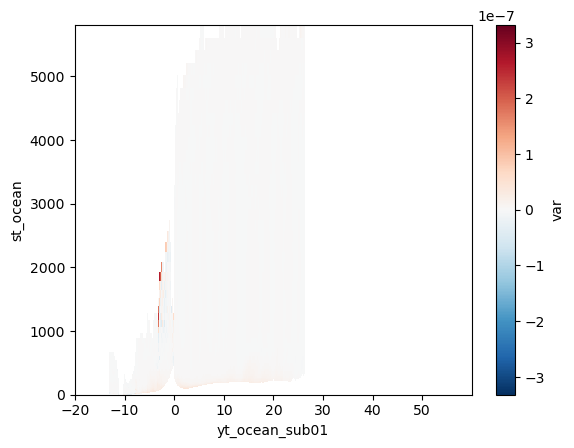

In [34]:
temp_advection_mean_time_ctrl_new.plot()

Text(0, 0.5, 'Temperature tendency anomaly ($^{\\circ}C\\ s^{-1}$)')

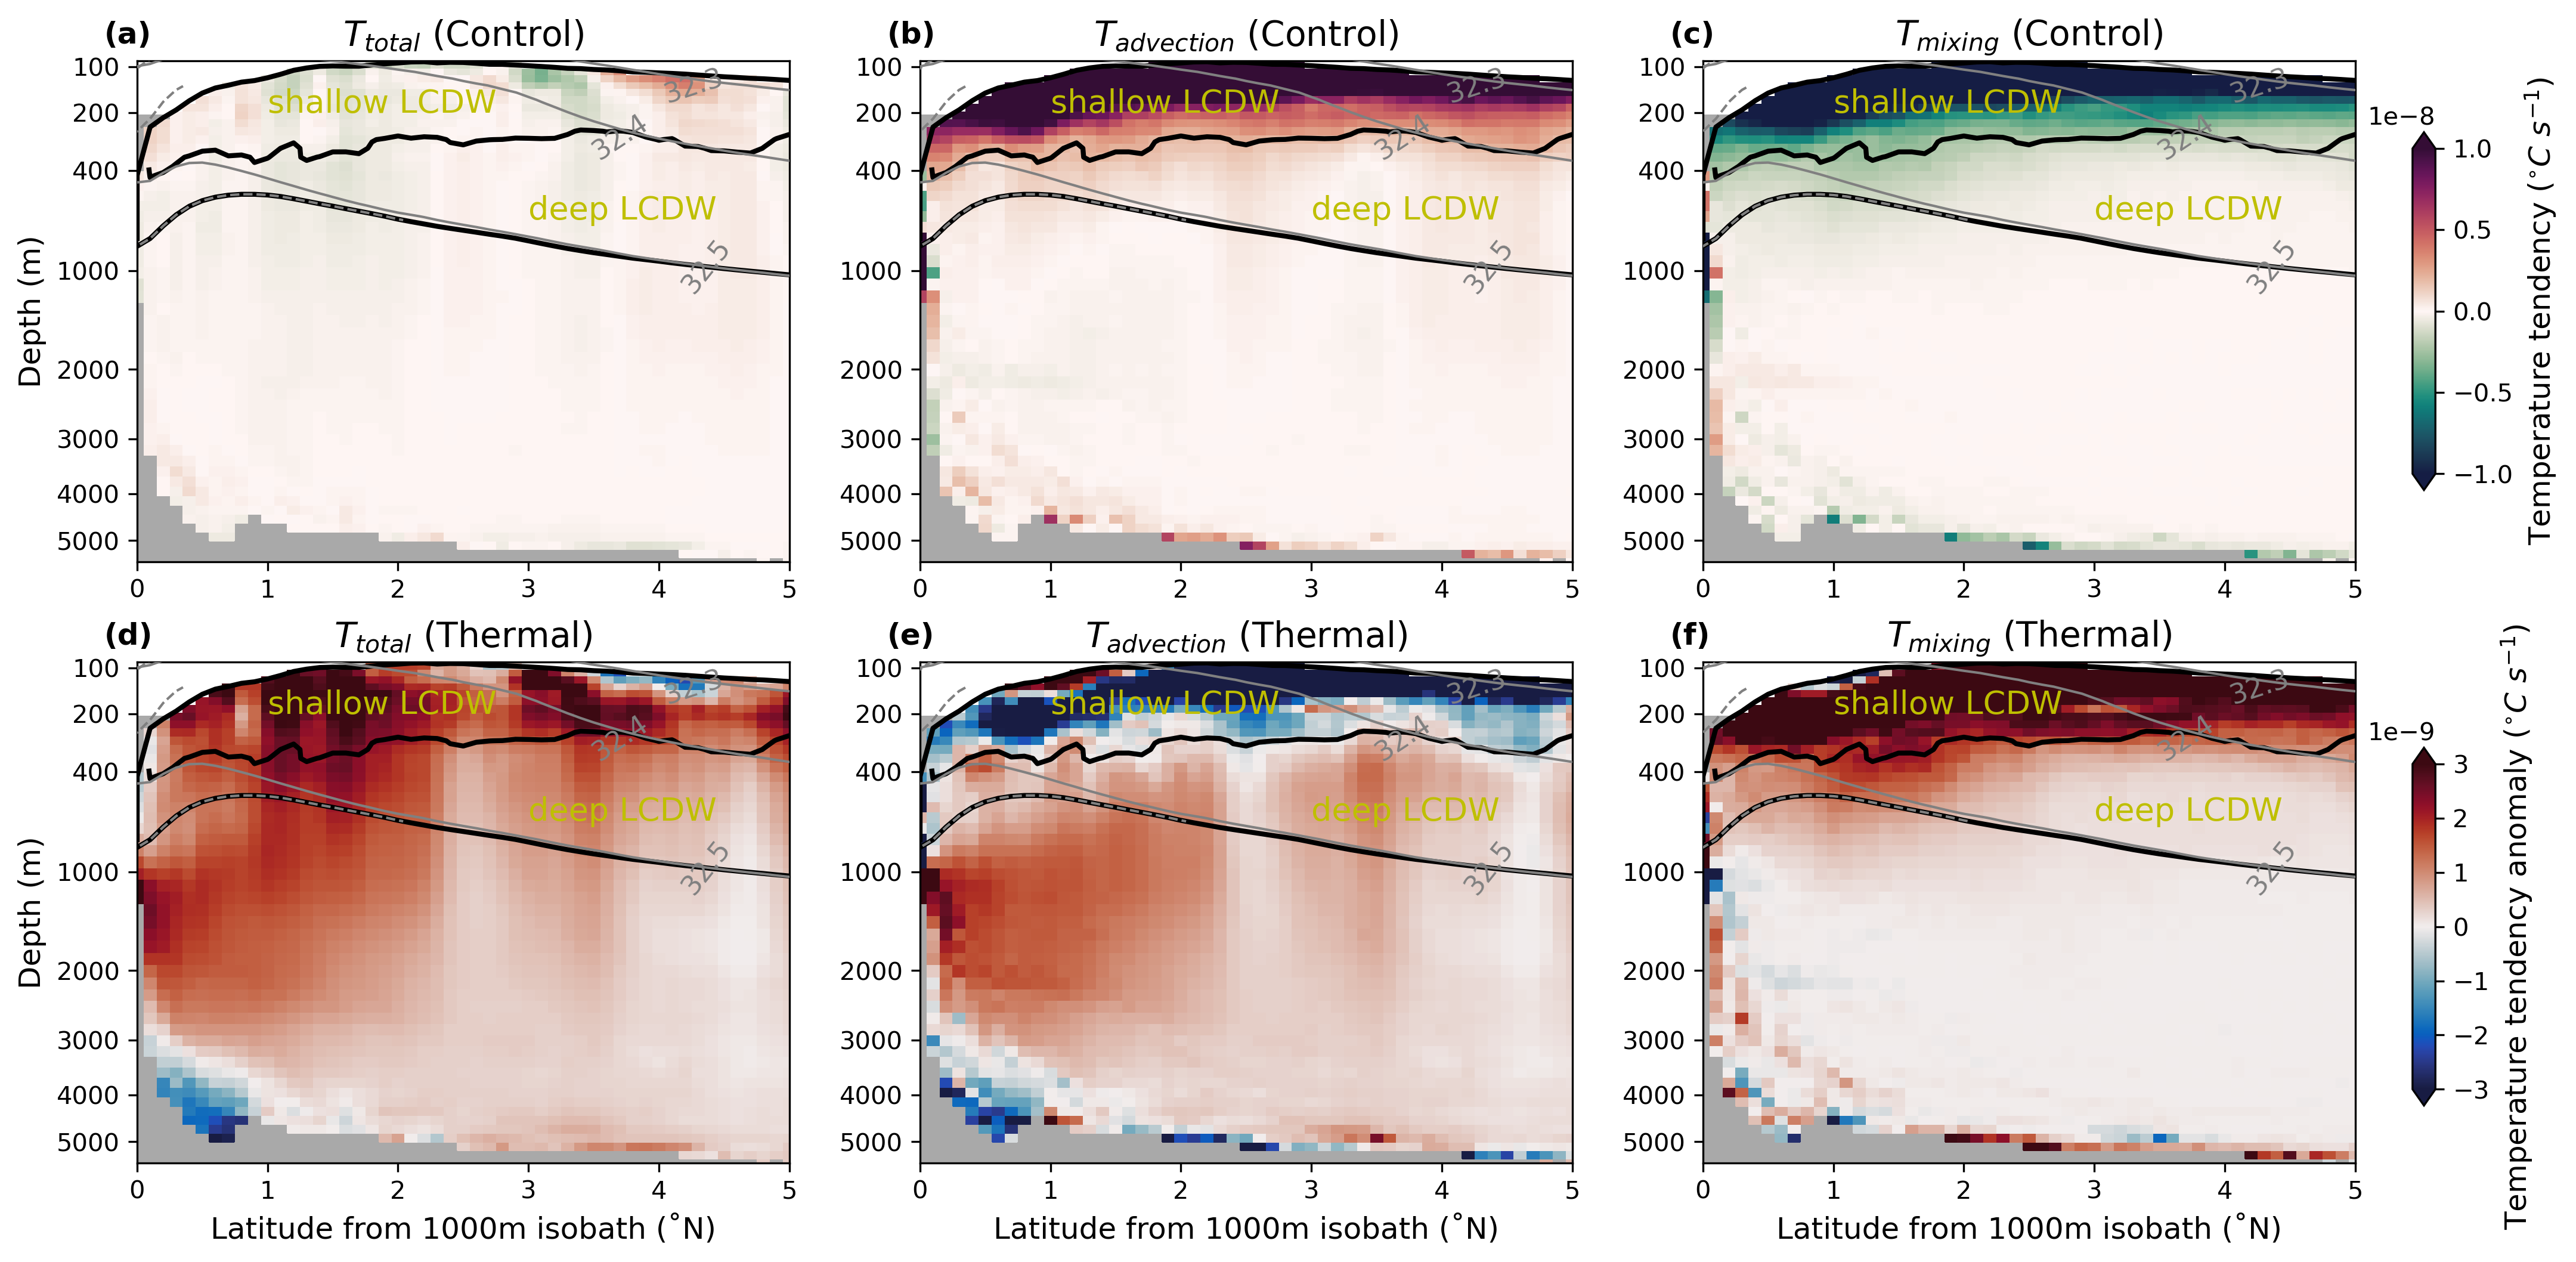

In [35]:
fig = plt.figure(figsize=(16,8),dpi = 300)

levs_dens = [32.3,32.4,32.5]
manual_positions = [
    (4, 200), 
    (3.5, 300),
    (4,1000)
]
for j in range(6):
    variable_name = ['Tendency Control','Advection Control','Mixing Control',
                    'Tendency Thermal','Advection Thermal','Mixing Thermal']
    title = ['$T_{total}$ (Control)','$T_{advection}$ (Control)','$T_{mixing}$ (Control)',
                    '$T_{total}$ (Thermal)','$T_{advection}$ (Thermal)','$T_{mixing}$ (Thermal)']
    text = ['(a)','(b)','(c)','(d)','(e)','(f)']
    ax = plt.subplot(2,3,j+1)
    background_1[30:,:].plot.contourf(ax=ax, colors='darkgrey', zorder=0,
                        add_colorbar=False)
    if j < 3:
        p1 = (data[variable_name[j]].sel(st_ocean = slice(1.,8000))).plot(vmin=-1e-8,vmax=1e-8, cmap = cm.cm.curl,add_colorbar = False)
        #plt.contour(temp_advection_mean_time_ctrl_new.yt_ocean_sub01.values,temp_advection_mean_time_ctrl_new[:41,:].st_ocean.values,temp_advection_mean_time_ctrl_new.sel(st_ocean = slice(0,600)),levels=[3e-9],colors='k',linestyles='--',linewidths=1.5,zorder=5)
        
    else:
        p2 = (data[variable_name[j]].sel(st_ocean = slice(1.,8000)) -data[variable_name[j-3]].sel(st_ocean = slice(1.,8000))).plot(vmin=-3e-9,vmax=3e-9, cmap = cm.cm.balance,add_colorbar = False)
    plt.contour(temp_advection_mean_time_ctrl_new.yt_ocean_sub01.values,temp_advection_mean_time_ctrl_new[:41,:].st_ocean.values,temp_advection_mean_time_ctrl_new.sel(st_ocean = slice(0,600)),levels=[2e-9],colors='k',linestyles='-',linewidths=2,zorder=5)
    plt.plot(bound_up_mean[200:300].yt_ocean.values, bound_up_mean[200:300].values, c = 'k',linewidth=2)
    plt.plot([10,10],[180,400], c = 'k',linewidth=2)
    plt.plot([10,10],[180,400], c = 'k',linewidth=2)
    #plt.plot([0,10],[350,350], c = 'k',linewidth=2)
    land.plot.contourf(ax=ax, colors='darkgrey', zorder=2,
                       add_colorbar=False)
    #land.fillna(0).plot.contour(ax=ax, colors='k', levels=[0, 1],
    #                        add_colorbar=False,linewidths = 0.6)    
    plt.plot(bound_up_mean[200:300].yt_ocean.values, bound_low_mean[200:300].values, c = 'k',linewidth=2)
    plt.plot([10,10],[400,bound_low_mean[300].values], c = 'k',linewidth=2)
    plt.plot([0,0],[400,bound_low_mean[201].values], c = 'k',linewidth=2)
    c2 = plt.contour(rho_mean_time_th.yt_ocean_sub01.values,rho_mean_time_ctrl[1:75,:].st_ocean.values,
                     rho_mean_time_ctrl.sel(st_ocean = slice(1.,8000))-1000,levels=levs_dens,colors='grey',linestyles='-',linewidths=1.,zorder=5)
    c2 = plt.contour(rho_mean_time_th.yt_ocean_sub01.values,rho_mean_time_th[1:75,:].st_ocean.values,
                     rho_mean_time_th.sel(st_ocean = slice(1.,8000))-1000,levels=levs_dens,colors='grey',linestyles='--',linewidths=1.,zorder=5)
    plt.clabel(c2,fontsize=11,inline=True,fmt='%1.1f',levels=levs_dens,manual = manual_positions)
    #plt.plot([-5,20], [400,400], linestyle='--', color='k')
    plt.ylim(90,5500)
    #plt.plot([-5,20], [200,200], linestyle='--', color='k')
    #plt.plot([-5,20], [100,100], linestyle='--', color='k')
    #plt.plot([-5,20], [50,50], linestyle='--', color='k')
    #plt.scatter(bound_low_th_mean.yt_ocean.values, bound_low_ctrl_mean.values, s = 0.1, c = 'b')
    #plt.scatter(bound_low_th_mean.yt_ocean.values, mld_ctrl_mean.values, s = 0.1, c = 'b')
    #plt.imshow(np.isnan(temp_tendency_mean_time_ctrl.values), cmap="grey", interpolation="none")
    def forward(x):
        return x**(1/3)
    def inverse(x):
        return x**3
    plt.gca().set_yscale('function', functions=(forward, inverse))
    plt.gca().invert_yaxis()
    plt.yticks([100,200,400,1000,2000,3000,4000,5000], [100,200,400,1000,2000,3000,4000,5000])  
    if (j) % 3 == 0:
        plt.ylabel('Depth (m)', fontsize = 12)
    else:
        plt.ylabel(' ', fontsize = 12)
    if j < 3:
        plt.xlabel(' ', fontsize = 12)
    else:
        plt.xlabel('Latitude from 1000m isobath (˚N)', fontsize = 12)
    
    plt.text(1,200,'shallow LCDW',fontsize = 13,color = 'y')
    plt.text(3,650,'deep LCDW',fontsize = 13,color = 'y')
    ax.text(
        -0.05, 1.08, f'{text[j]}', transform=ax.transAxes, fontweight='bold', 
        fontsize=12,  # Font size
        verticalalignment='top',  # Align text vertically to the top
        horizontalalignment='left',  # Align text horizontally to the left
    )
    #plt.ylabel('depth (m)', fontsize = 12)
    plt.xlim(0,5)
    ax.set_title(f'{title[j]}', fontsize = 14)
    # colorbars
ax_cb1 = plt.axes([0.92, 0.58, 0.008, 0.25])
cb = plt.colorbar(p1, cax=ax_cb1,  orientation='vertical',extend='both')
cb.ax.set_ylabel('Temperature tendency ($^{\circ}C\ s^{-1}$)', fontsize = 12)

ax_cb1 = plt.axes([0.92, 0.15, 0.008, 0.25])
cb = plt.colorbar(p2, cax=ax_cb1,  orientation='vertical',extend='both')
cb.ax.set_ylabel('Temperature tendency anomaly ($^{\circ}C\ s^{-1}$)', fontsize = 12)

In [36]:
data1 = xr.Dataset({
    'Vertical diffusion': temp_vdiffuse_diff_cbt_mean_time_th_new,
    'Non-local KPP': temp_nonlocal_KPP_mean_time_th_new
})


Text(0, 0.5, 'Temperature tendency anomaly ($^{\\circ}C\\ s^{-1}$)')

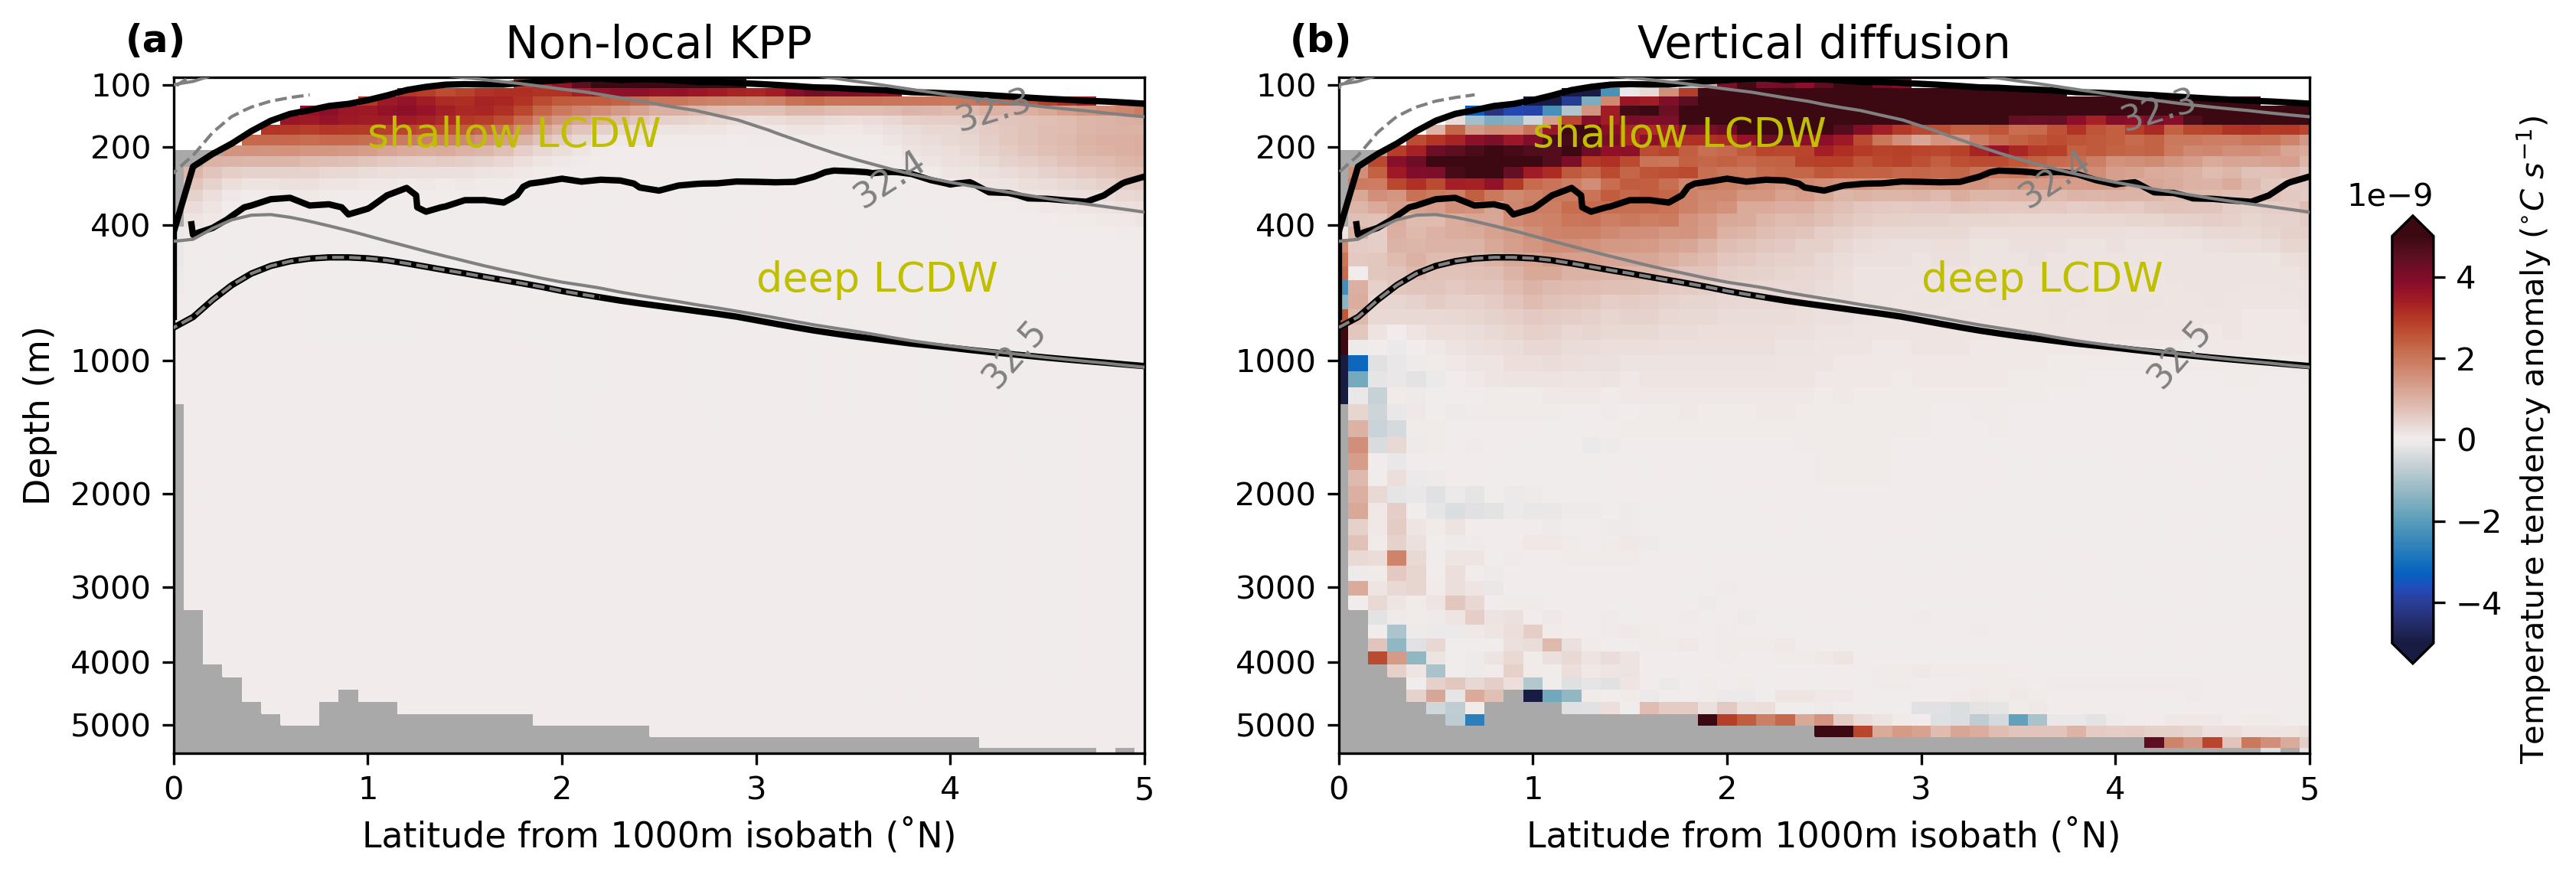

In [37]:
fig = plt.figure(figsize=(12,13),dpi = 300)

levs_dens = [32.3,32.4,32.5]
manual_positions = [
    (4, 200), 
    (3.5, 300),
    (4,1000)
]
for j in range(2):
    variable_name = ['Non-local KPP','Vertical diffusion']
#    title = ['$T_{total}$ (Control)','$T_{advection}$ (Control)','$T_{mixing}$ (Control)',
#                    '$T_{total}$ (Thermal)','$T_{advection}$ (Thermal)','$T_{mixing}$ (Thermal)']
    text = ['(a)','(b)']
    ax = plt.subplot(3,2,j+5)
    background_1[30:,:].plot.contourf(ax=ax, colors='darkgrey', zorder=0,
                        add_colorbar=False)
    if j == 0:
        p2 = (data1[variable_name[j]].sel(st_ocean = slice(1.,8000)) -temp_nonlocal_KPP_mean_time_ctrl_new.sel(st_ocean = slice(1.,8000))).plot(vmin=-5e-9,vmax=5e-9, cmap = cm.cm.balance,add_colorbar = False)
        
    else:
        p2 = (data1[variable_name[j]].sel(st_ocean = slice(1.,8000)) -temp_vdiffuse_diff_cbt_mean_time_ctrl_new.sel(st_ocean = slice(1.,8000))).plot(vmin=-5e-9,vmax=5e-9, cmap = cm.cm.balance,add_colorbar = False)
    plt.contour(temp_advection_mean_time_ctrl_new.yt_ocean_sub01.values,temp_advection_mean_time_ctrl_new[:41,:].st_ocean.values,temp_advection_mean_time_ctrl_new.sel(st_ocean = slice(0,600)),levels=[2e-9],colors='k',linestyles='-',linewidths=2,zorder=5)
    plt.plot(bound_up_mean[200:300].yt_ocean.values, bound_up_mean[200:300].values, c = 'k',linewidth=2)
    plt.plot([10,10],[180,400], c = 'k',linewidth=2)
    plt.plot([10,10],[180,400], c = 'k',linewidth=2)
    #plt.plot([0,10],[350,350], c = 'k',linewidth=2)
    land.plot.contourf(ax=ax, colors='darkgrey', zorder=2,
                       add_colorbar=False)
    #land.fillna(0).plot.contour(ax=ax, colors='k', levels=[0, 1],
    #                        add_colorbar=False,linewidths = 0.6)    
    plt.plot(bound_up_mean[200:300].yt_ocean.values, bound_low_mean[200:300].values, c = 'k',linewidth=2)
    plt.plot([10,10],[400,bound_low_mean[300].values], c = 'k',linewidth=2)
    plt.plot([0,0],[400,bound_low_mean[201].values], c = 'k',linewidth=2)
    c2 = plt.contour(rho_mean_time_th.yt_ocean_sub01.values,rho_mean_time_ctrl[1:75,:].st_ocean.values,
                     rho_mean_time_ctrl.sel(st_ocean = slice(1.,8000))-1000,levels=levs_dens,colors='grey',linestyles='-',linewidths=1.,zorder=5)
    c2 = plt.contour(rho_mean_time_th.yt_ocean_sub01.values,rho_mean_time_th[1:75,:].st_ocean.values,
                     rho_mean_time_th.sel(st_ocean = slice(1.,8000))-1000,levels=levs_dens,colors='grey',linestyles='--',linewidths=1.,zorder=5)
    plt.clabel(c2,fontsize=11,inline=True,fmt='%1.1f',levels=levs_dens,manual = manual_positions)
    #plt.plot([-5,20], [400,400], linestyle='--', color='k')
    plt.ylim(90,5500)
    #plt.plot([-5,20], [200,200], linestyle='--', color='k')
    #plt.plot([-5,20], [100,100], linestyle='--', color='k')
    #plt.plot([-5,20], [50,50], linestyle='--', color='k')
    #plt.scatter(bound_low_th_mean.yt_ocean.values, bound_low_ctrl_mean.values, s = 0.1, c = 'b')
    #plt.scatter(bound_low_th_mean.yt_ocean.values, mld_ctrl_mean.values, s = 0.1, c = 'b')
    #plt.imshow(np.isnan(temp_tendency_mean_time_ctrl.values), cmap="grey", interpolation="none")
    def forward(x):
        return x**(1/3)
    def inverse(x):
        return x**3
    plt.gca().set_yscale('function', functions=(forward, inverse))
    plt.gca().invert_yaxis()
    plt.yticks([100,200,400,1000,2000,3000,4000,5000], [100,200,400,1000,2000,3000,4000,5000])  
    if (j) % 2 == 0:
        plt.ylabel('Depth (m)', fontsize = 11)
    else:
        plt.ylabel(' ', fontsize = 12)
    if j < 3:
        plt.xlabel('Latitude from 1000m isobath (˚N)', fontsize = 11)
    
    plt.text(1,200,'shallow LCDW',fontsize = 13,color = 'y')
    plt.text(3,650,'deep LCDW',fontsize = 13,color = 'y')
    ax.text(
        -0.05, 1.08, f'{text[j]}', transform=ax.transAxes, fontweight='bold', 
        fontsize=12,  # Font size
        verticalalignment='top',  # Align text vertically to the top
        horizontalalignment='left',  # Align text horizontally to the left
    )
    #plt.ylabel('depth (m)', fontsize = 12)
    plt.xlim(0,5)
    ax.set_title(f'{variable_name[j]}', fontsize = 14)
    # colorbars

ax_cb1 = plt.axes([0.93, 0.14, 0.015, 0.15])
cb = plt.colorbar(p2, cax=ax_cb1,  orientation='vertical',extend='both')
cb.ax.set_ylabel('Temperature tendency anomaly ($^{\circ}C\ s^{-1}$)', fontsize = 10)

In [35]:
temp_advection_mean_time_ctrl_new.to_netcdf('/g/data/x77/hm1221/PhD_P1_data/bound_mid_mean.nc')

In [36]:
custom_x_ctrl = np.linspace(0, 1., 36)

custom_ticks = np.concatenate([
    np.linspace(0.0, 1., 36),
])
custom_tick_labels = ['2','','','','','','','','','','', '3','', '', '', '', '', '', '', '','','','','4',
                     '','','','','','','','','','','','5']

Text(0.0, 1.05, '(b)')

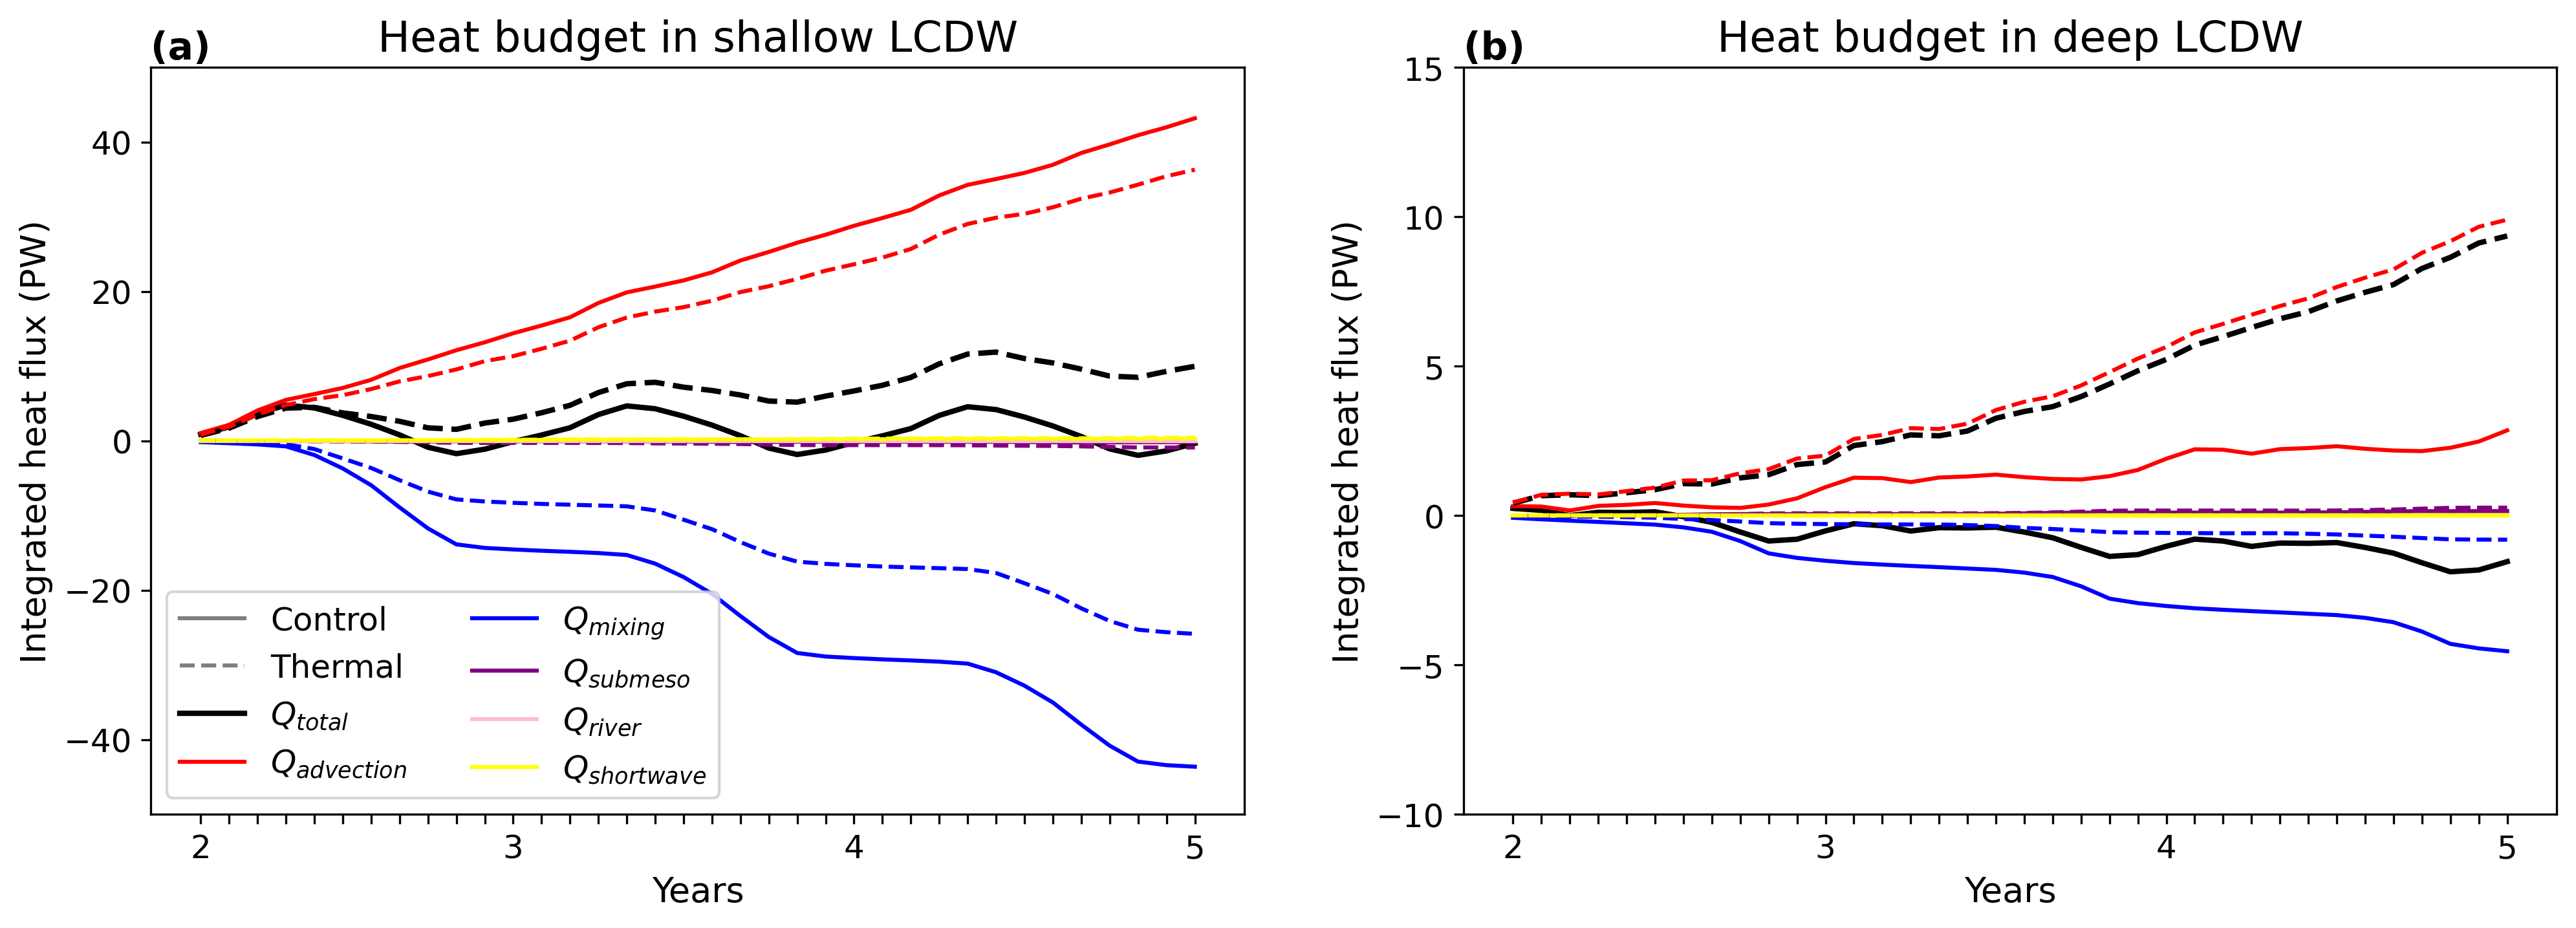

In [37]:
fig = plt.figure(figsize=(16,5),dpi = 300)
ax = plt.subplot(1,2,1)
plt.plot(0,0,color = 'grey',linestyle='-')
plt.plot(0,0,color = 'grey',linestyle='--')
plt.plot(custom_x_ctrl,(tendency_box_ctrl_upper/3e16).values,color = 'k',linestyle='-',linewidth = 2)
plt.plot(custom_x_ctrl,(advection_box_ctrl_upper/3e16).values,color = 'r',linestyle='-')
plt.plot(custom_x_ctrl,(diffuse_box_ctrl_upper/3e16).values+(KPP_box_ctrl_upper/3e16).values,color = 'b',linestyle='-')
plt.plot(custom_x_ctrl,(submeso_box_ctrl_upper/3e16).values,color = 'purple',linestyle='-')
plt.plot(custom_x_ctrl,(river_mix_box_ctrl_upper/3e16).values,color = 'pink',linestyle='-')
plt.plot(custom_x_ctrl,(sw_box_ctrl_upper/3e16).values,color = 'yellow',linestyle='-')
plt.legend(['Control','Thermal','$Q_{total}$','$Q_{advection}$','$Q_{mixing}$','$Q_{submeso}$','$Q_{river}$','$Q_{shortwave}$'],
           fontsize = 12,loc = 'lower left',ncol=2)
#plt.legend(['Control','Thermal','$T_{total}$','$T_{advection}$','$T_{mixing}$','$T_{submeso}$','$T_{river}$','$T_{shortwave}$'],fontsize = 11)
#plt.legend(['temp_tendency','advection','mixing','temp_submeso','rivermix','shortwave'])
plt.plot(custom_x_ctrl,(tendency_box_th_upper/3e16).values,color = 'k',linestyle='--',linewidth = 2)
plt.plot(custom_x_ctrl,(advection_box_th_upper/3e16).values,color = 'r',linestyle='--')
plt.plot(custom_x_ctrl,(diffuse_box_th_upper/3e16).values+(KPP_box_th_upper.values/3e16),color = 'b',linestyle='--')
plt.plot(custom_x_ctrl,(submeso_box_th_upper/3e16).values,color = 'purple',linestyle='--')
plt.plot(custom_x_ctrl,(river_mix_box_th_upper/3e16).values,color = 'pink',linestyle='--')
plt.plot(custom_x_ctrl,(sw_box_th_upper/3e16).values,color = 'yellow',linestyle='--')
ax.text(
        0.0, 1.05,'(a)', transform=ax.transAxes, fontweight='bold', 
        fontsize=14,  # Font size
        verticalalignment='top',  # Align text vertically to the top
        horizontalalignment='left',  # Align text horizontally to the left
)
plt.title('Heat budget in shallow LCDW', fontsize = 16)

#months = ['01-01', '02-01', '03-01', '04-01', '05-01', '06-01', '07-01','08-01','09-01','10-01']
#tick_positions = [np.where(dates == month)[0][0] for month in months]
plt.ylim(-5e16/1e15,5e16/1e15)
plt.xlabel('Years',fontsize = 13)
plt.ylabel('Integrated heat flux (PW)',fontsize = 13)
plt.xticks(custom_ticks, custom_tick_labels,fontsize = 12)
plt.yticks(fontsize = 12)
ax = plt.subplot(1,2,2)
plt.plot(0,0,color = 'k',linestyle='-')
plt.plot(0,0,color = 'k',linestyle='--')
plt.plot(custom_x_ctrl,(tendency_box_ctrl_lower/3e16).values,color = 'k',linestyle='-',linewidth = 2)
plt.plot(custom_x_ctrl,(advection_box_ctrl_lower/3e16).values,color = 'r',linestyle='-')
plt.plot(custom_x_ctrl,(diffuse_box_ctrl_lower/3e16).values+(KPP_box_ctrl_lower/3e16).values,color = 'b',linestyle='-')
plt.plot(custom_x_ctrl,(submeso_box_ctrl_lower/3e16).values,color = 'purple',linestyle='-')
plt.plot(custom_x_ctrl,(river_mix_box_ctrl_lower/3e16).values,color = 'pink',linestyle='-')
plt.plot(custom_x_ctrl,(sw_box_ctrl_lower/3e16).values,color = 'yellow',linestyle='-')
#plt.legend(['Control','Thermal','$T_{total}$','$T_{advection}$','$T_{mixing}$','$T_{submeso}$','$T_{river}$','$T_{shortwave}$'],fontsize = 12)
#plt.legend(['Control','Thermal','$T_{advection}$','$T_{mixing}$','$T_{shortwave}$','$T_{submeso}$','$T_{submeso}$','$T_{shortwave}$'],fontsize = 11)
plt.plot(custom_x_ctrl,(tendency_box_th_lower/3e16).values,color = 'k',linestyle='--',linewidth = 2)
plt.plot(custom_x_ctrl,(advection_box_th_lower/3e16).values,color = 'r',linestyle='--')
plt.plot(custom_x_ctrl,(diffuse_box_th_lower/3e16).values+(KPP_box_th_lower/3e16).values,color = 'b',linestyle='--')
plt.plot(custom_x_ctrl,(submeso_box_th_lower/3e16).values,color = 'purple',linestyle='--')
plt.plot(custom_x_ctrl,(river_mix_box_th_lower/3e16).values,color = 'pink',linestyle='--')
plt.plot(custom_x_ctrl,(sw_box_th_lower/3e16).values,color = 'yellow',linestyle='--')
plt.title('Heat budget in deep LCDW', fontsize = 16)
#months = ['01-01', '02-01', '03-01', '04-01', '05-01', '06-01', '07-01','08-01','09-01','10-01']
#tick_positions = [np.where(dates == month)[0][0] for month in months]
plt.ylim(-1e16/1e15,1.5e16/1e15)
plt.xlabel('Years',fontsize = 13)
plt.ylabel('Integrated heat flux (PW)',fontsize = 13)
#plt.xticks(np.arange(3,5,1), np.arange(3,5,1), fontsize = 12)
plt.xticks(custom_ticks, custom_tick_labels,fontsize = 12)
plt.yticks(fontsize = 12)
ax.text(
        0., 1.05,'(b)', transform=ax.transAxes, fontweight='bold', 
        fontsize=14,  # Font size
        verticalalignment='top',  # Align text vertically to the top
        horizontalalignment='left',  # Align text horizontally to the left
)